# 02 — Fairness Audit: Error-Rate Parity, Predictive Parity, Calibration

Uses `src/audit.py`. We treat `decile_score >= 5` (COMPAS's own Medium/High cutoff)
as the tool's "high risk" prediction, and `two_year_recid` as ground truth.

Three fairness definitions are checked, because a system can be non-discriminatory
under one definition and discriminatory under another — this is a mathematical
fact (Chouldechova 2017; Kleinberg, Mullainathan & Raghavan 2016), not a modeling
choice:

1. **Predictive parity** — precision (PPV) is similar across groups: "when the tool
   says high-risk, is it equally likely to be right for everyone?"
2. **Error-rate / equalized-odds parity** — false-positive and false-negative rates
   are similar across groups: "is everyone equally likely to be wrongly flagged, or
   wrongly cleared?"
3. **Calibration** — within a given score, actual recidivism rate is similar across
   groups: "does a '7' mean the same thing regardless of race?"

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import matplotlib.pyplot as plt
from audit import group_metrics, disparate_impact_ratio, equalized_odds_gap, fpr_gap_significance, calibration_by_group

df = pd.read_csv("../data/raw/compas_scores.csv")
df["pred_high_risk"] = (df["decile_score"] >= 5).astype(int)
df_2race = df[df["race"].isin(["African-American", "Caucasian"])].copy()
print(len(df_2race))

5278


## Group confusion-matrix metrics

In [2]:
metrics = group_metrics(df_2race, "race", "two_year_recid", "pred_high_risk")
metrics

,group,n,base_rate,selection_rate,fpr,fnr,tpr,tnr,ppv,npv,accuracy
0,African-American,3175,0.52315,0.576063,0.423382,0.284768,0.715232,0.576618,0.649535,0.648588,0.649134
1,Caucasian,2103,0.39087,0.330956,0.220141,0.496350,0.503650,0.779859,0.594828,0.710021,0.671897


## Predictive parity check

PPV (precision) is reasonably close across groups — this is the metric COMPAS's
vendor (Northpointe/Equivant) pointed to in their rebuttal to ProPublica, arguing the
tool is fair.

In [3]:
metrics[["group", "ppv", "npv"]]

,group,ppv,npv
0,African-American,0.649535,0.648588
1,Caucasian,0.594828,0.710021


## Error-rate parity check — the crux of ProPublica's finding

False positive rate: among people who did **not** reoffend, what fraction were
wrongly flagged high-risk? False negative rate: among people who **did** reoffend,
what fraction were wrongly cleared as low-risk?

In [4]:
metrics[["group", "n", "fpr", "fnr"]]

,group,n,fpr,fnr
0,African-American,3175,0.423382,0.284768
1,Caucasian,2103,0.220141,0.496350


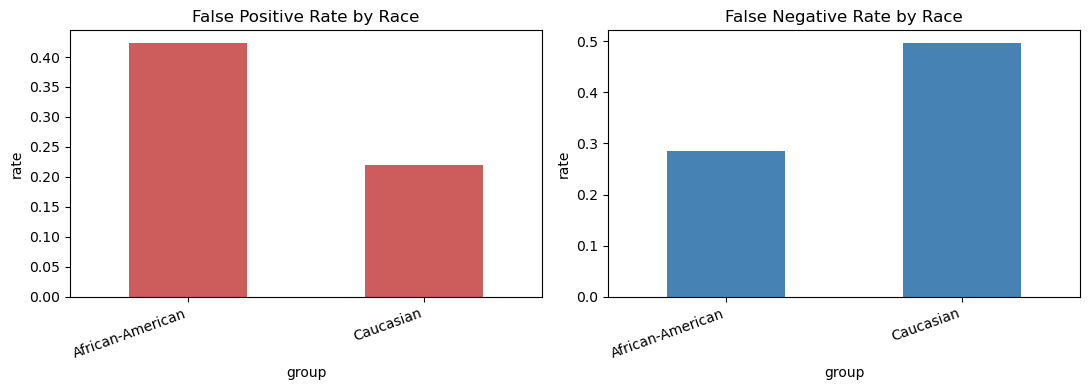

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics.set_index("group")["fpr"].plot(kind="bar", ax=axes[0], color="indianred", title="False Positive Rate by Race")
metrics.set_index("group")["fnr"].plot(kind="bar", ax=axes[1], color="steelblue", title="False Negative Rate by Race")
for ax in axes:
    ax.set_ylabel("rate")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../outputs/error_rates_by_race.png", dpi=120, bbox_inches="tight")
plt.show()

## Statistical significance of the FPR gap

Is the false-positive-rate gap distinguishable from noise, or could it plausibly be
sampling variation? A two-proportion z-test on the actual-non-recidivist subgroup
answers this directly.

In [6]:
sig = fpr_gap_significance(df_2race, "race", "two_year_recid", "pred_high_risk", "African-American", "Caucasian")
print(f"FPR (African-American): {sig['fpr_a']:.1%}")
print(f"FPR (Caucasian):        {sig['fpr_b']:.1%}")
print(f"z-statistic: {sig['z']:.2f}")
print(f"p-value:     {sig['p_value']:.2e}")

FPR (African-American): 42.3%
FPR (Caucasian):        22.0%
z-statistic: 11.38
p-value:     0.00e+00


The gap is not remotely explainable by chance — this independently reproduces
ProPublica's 2016 finding (they reported ~44.9% vs. ~23.5%; this reduced dataset gives
~42.3% vs. ~22.0%, the same story to within a couple points).

## Disparate impact ratio (selection rate ratio, the "80% rule")

In [7]:
di = disparate_impact_ratio(metrics, privileged_group="Caucasian")
di[["group", "selection_rate", "disparate_impact_ratio", "fails_80pct_rule"]]

,group,selection_rate,disparate_impact_ratio,fails_80pct_rule
0,African-American,0.576063,1.740604,False
1,Caucasian,0.330956,1.000000,False


## Equalized odds gap (summary number used in `03_mitigation.ipynb`)

In [8]:
gap = equalized_odds_gap(metrics)
gap

{'fpr_gap': 0.203241254922828,
 'tpr_gap': 0.2115821530429738,
 'equalized_odds_gap': 0.2115821530429738}

## Calibration by score

Within each decile score, does the *actual* recidivism rate line up across race
groups? If a '7' means genuinely different things by race, the score is poorly
calibrated for at least one group.

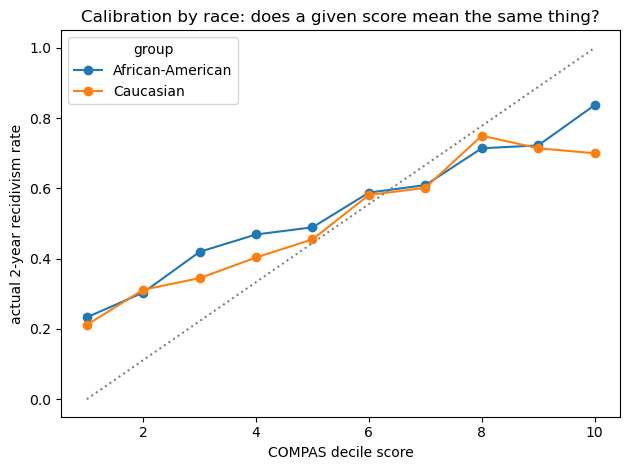

In [9]:
cal = calibration_by_group(df_2race, "race", "decile_score", "two_year_recid")
pivot = cal.pivot(index="score", columns="group", values="actual_recid_rate")

fig, ax = plt.subplots()
pivot.plot(marker="o", ax=ax)
ax.plot([1, 10], [0, 1], linestyle=":", color="gray", label="reference")
ax.set_xlabel("COMPAS decile score")
ax.set_ylabel("actual 2-year recidivism rate")
ax.set_title("Calibration by race: does a given score mean the same thing?")
plt.tight_layout()
plt.savefig("../outputs/calibration_by_race.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

COMPAS is reasonably **calibrated** and shows similar **predictive parity** (PPV)
across race groups — this is the basis of the vendor's fairness defense. But it
fails **error-rate parity** badly and with high statistical significance: Black
defendants who did *not* reoffend were flagged high-risk at roughly **twice** the
rate of White defendants who did not reoffend. Both claims are simultaneously true,
which is exactly the mathematical impossibility result in the fairness literature —
no single number settles whether a system is "fair."

Next: `03_mitigation.ipynb` — can post-processing fix the error-rate gap, and at what
cost?